In [1]:
!pip install yfinance

  Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 199.7 kB/s eta 0:00:08
   ---------- ----------------------------- 0.5/2.0 MB 199.7 kB/s eta 0:00:08
   --------------- ------------------------ 0.8/2.0 MB 310.6 kB/s eta 0:00:04
   --------------- ------------------------ 0.8/2.0 MB 310.6 kB/s et

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [4]:
tcs = yf.download("TCS.NS", start = "2010-04-01", end = "2026-04-01")
tcs.head()
tcs.to_csv("dataset.csv", index=True)

[*********************100%***********************]  1 of 1 completed


In [5]:
tcs.info()
# no missing values

<class 'pandas.DataFrame'>
DatetimeIndex: 3950 entries, 2010-04-01 to 2026-03-30
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   3950 non-null   float64
 1   (High, TCS.NS)    3950 non-null   float64
 2   (Low, TCS.NS)     3950 non-null   float64
 3   (Open, TCS.NS)    3950 non-null   float64
 4   (Volume, TCS.NS)  3950 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 185.2 KB


In [6]:
tcs.columns = ["close", "high", "low", "open", "volume"]

In [7]:
#data quality and stucture check
#datatype of index- expected DatetimeIndex
print(type(tcs.index))
#increasing index
print(tcs.index.is_monotonic_increasing)
#duplicate index
print(tcs.index.duplicated().sum())
#number of holidays exculding sat and sun
all_days = pd.date_range(start=tcs.index.min(), end=tcs.index.max(), freq='B')
missing_days = all_days.difference(tcs.index)
print(len(missing_days))
#invalid prices
print((tcs[['open','high','low','close']] <= 0).sum())
# validity of constraints based on high low
invalid_high = (tcs['high'] < tcs[['open','close']].max(axis=1)).sum()
invalid_low  = (tcs['low']  > tcs[['open','close']].min(axis=1)).sum()
print(invalid_high, ",", invalid_low)
#volume anamoly
print((tcs['volume'] == 0).sum())

<class 'pandas.DatetimeIndex'>
True
0
226
open     0
high     0
low      0
close    0
dtype: int64
0 , 0
4


In [8]:
tcs.describe()


,close,high,low,open,volume
count,3950.000000,3950.000000,3950.000000,3950.000000,3.950000e+03
mean,1704.946245,1722.139716,1688.456154,1705.786209,2.738542e+06
std,1137.794111,1147.859925,1128.620275,1138.500031,2.151597e+06
min,240.609467,245.579533,235.690922,243.515735,0.000000e+00
25%,810.566269,817.615836,797.508682,809.193950,1.692329e+06
50%,1254.842468,1269.196187,1240.559065,1254.076791,2.309856e+06
75%,2885.532654,2910.869665,2861.054057,2888.897437,3.222885e+06
max,4230.708984,4266.477811,4191.921772,4251.381655,8.806715e+07


In [9]:
tcs.head()

,close,high,low,open,volume
Date,,,,,
2010-04-01,277.841766,278.529664,269.002280,270.464062,5781432
2010-04-05,276.311279,281.006189,274.901098,281.006189,3001836
2010-04-06,273.800537,278.220293,272.459149,278.220293,3702366
2010-04-07,274.488251,278.254493,268.675530,271.719468,3024558
2010-04-08,274.969849,277.738632,271.719529,273.783221,4494438


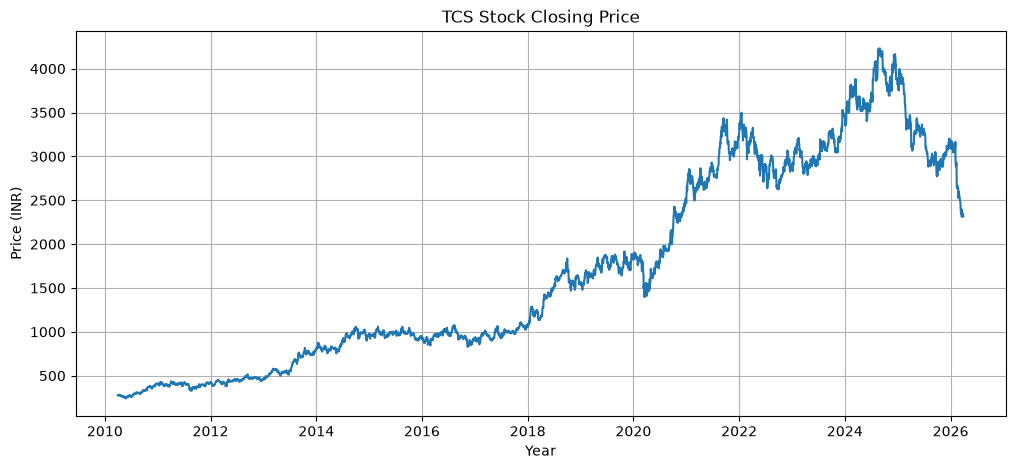

In [10]:
plt.figure(figsize=(12,5))
plt.plot(tcs['close'])
plt.title("TCS Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [11]:
#moving meadian or averages weekly basis
close_ma = []
wsize = 7;
sum = 3;
for i in range(wsize):
    sum+= tcs['close'].iloc[i]
    close_ma.append(int(sum/ (i+1)));

for i in range(wsize, len(tcs['close'])):
    sum -= tcs['close'].iloc[i - wsize]
    sum+= tcs['close'].iloc[i]
    close_ma.append(int(sum/wsize));

close_ma_series = pd.Series(close_ma, index=tcs.index)

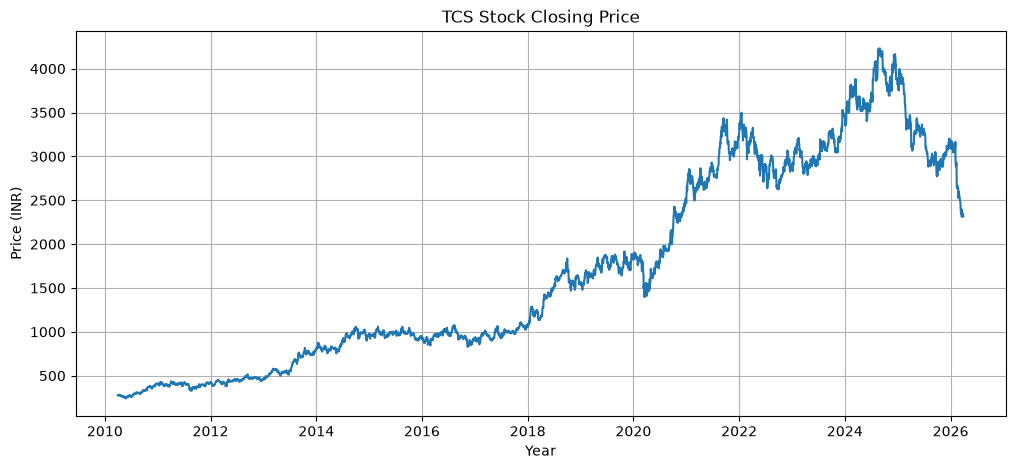

In [12]:
# trend and stationary test
plt.figure(figsize=(12,5))
plt.plot(tcs['close'])
plt.title("TCS Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()
# plot shows a persistent upward movement - upward trend, implies non-stationary nature

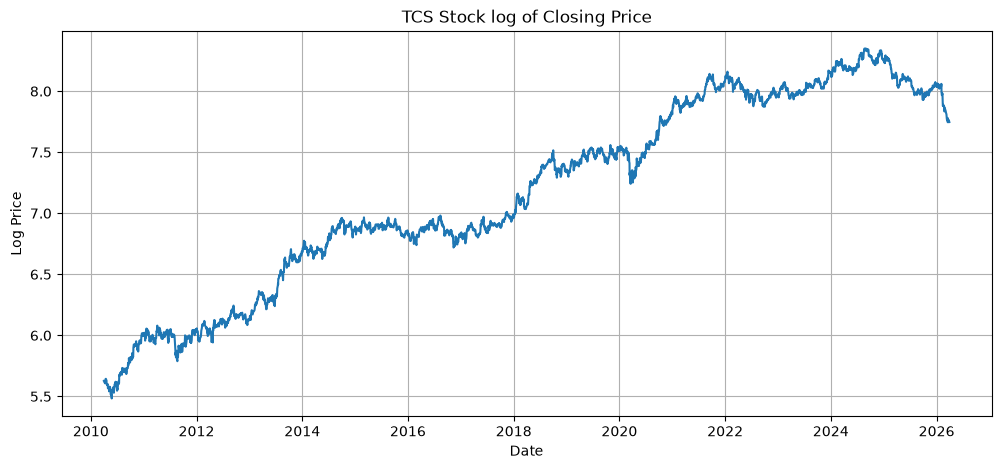

In [13]:
#log price plot
plt.figure(figsize = (12, 5))
plt.plot(tcs.index, np.log(tcs['close']))
plt.title("TCS Stock log of Closing Price")
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.grid(True)
plt.show()
#linear log trend - exponential growth

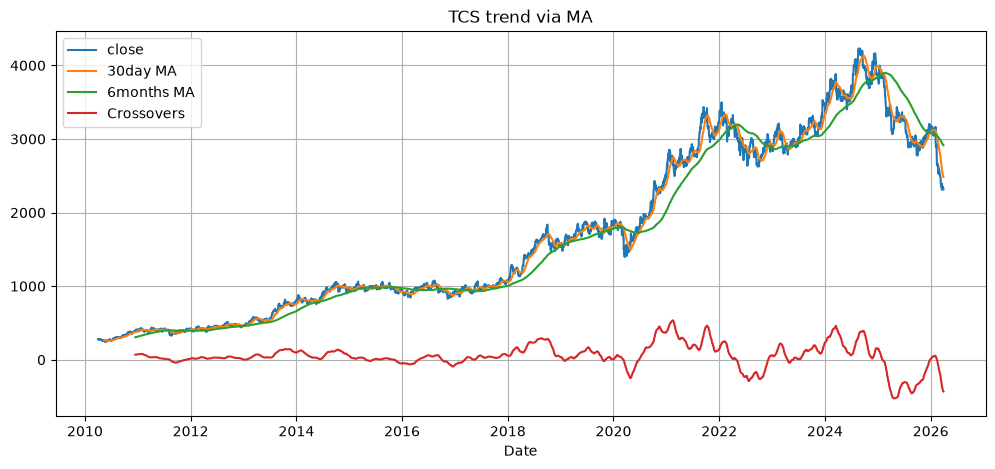

In [14]:
#trend smoothing
plt.figure(figsize = (12, 5))
plt.plot(tcs.index, tcs['close'], label = 'close')
plt.plot(tcs.index, tcs['close'].rolling(30).mean(), label = '30day MA')
plt.plot(tcs.index, tcs['close'].rolling(180).mean(), label = '6months MA')
plt.plot(tcs.index, (tcs['close'].rolling(30).mean() - tcs['close'].rolling(180).mean()), label = 'Crossovers')
#you see most of the buyers dominate the market, bullish regime(golden cross), better for long term investors, trend aware models
#intermittent bearish regime- favours frequent retraing help in deciding Foracast intervals
plt.legend()
plt.title('TCS trend via MA')
plt.grid(True)
plt.xlabel('Date')
plt.show()

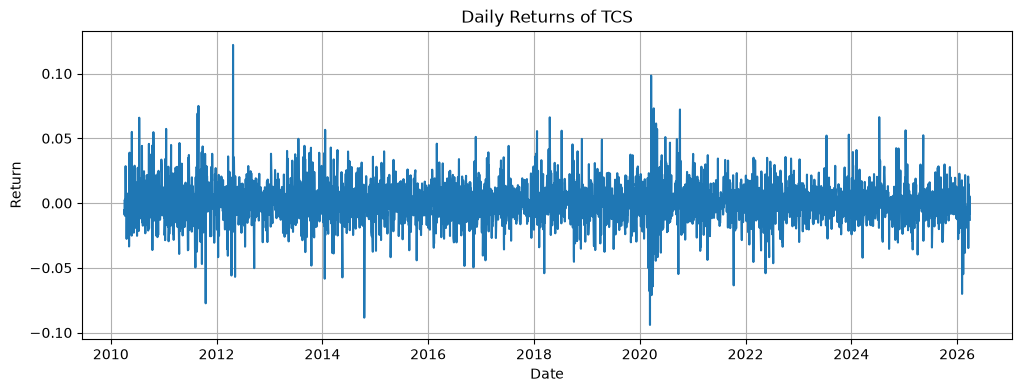

In [15]:
#daily return- volatility test - sudden rise or fall suggest regime breaks -favours frequent retraing, PI
tcs['return'] = tcs['close'].pct_change()
plt.figure(figsize=(12,4))
plt.plot(tcs.index, tcs['return'])
plt.title("Daily Returns of TCS")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

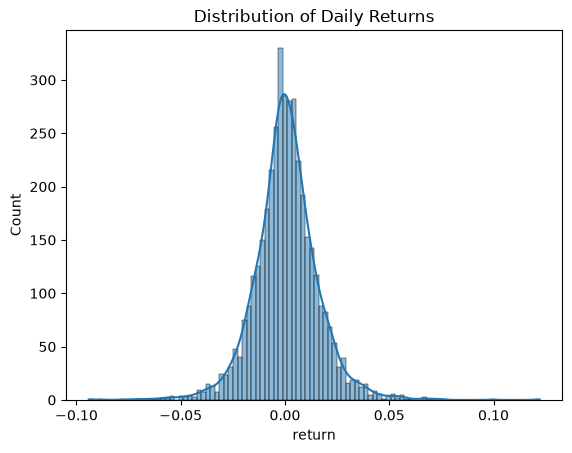

In [16]:
#daily return distribution- tests about distribution of return- close to normal
# most of the time remain close to zero
# more stable training
sns.histplot(tcs['return'].dropna(), bins=100, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

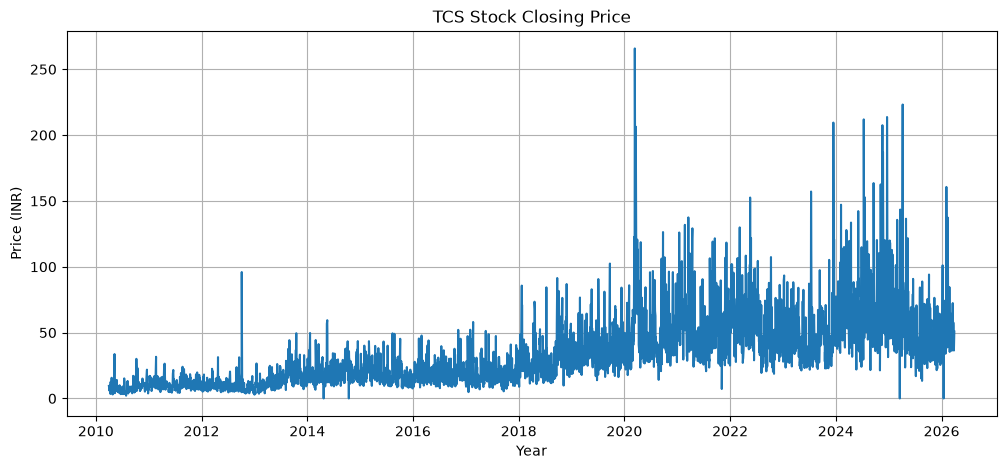

In [17]:
#intraday volatility
#persistent intraday volatility increase
tcs['range'] = tcs['high'] - tcs['low']
plt.figure(figsize=(12,5))
plt.plot(tcs['range'])
plt.title("TCS Stock Closing Price")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

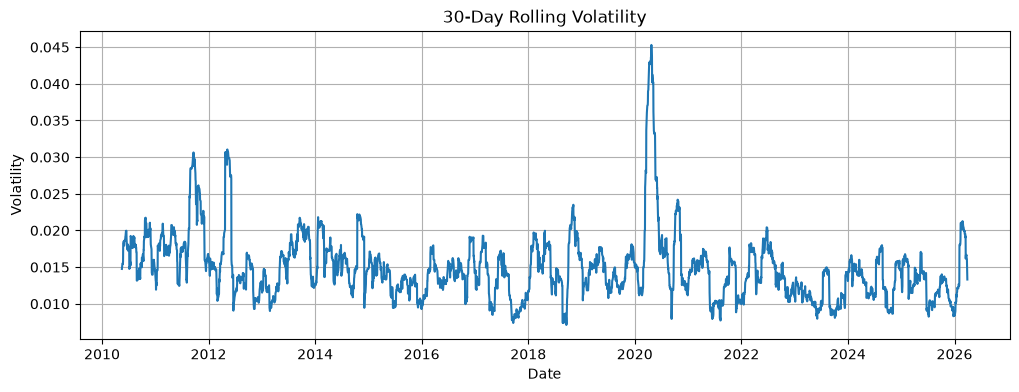

In [18]:
#sudden volatility sudden volatility changes marks, regime shift, market fluctutions, clustering
tcs['vol_30'] = tcs['return'].rolling(30).std()
plt.figure(figsize=(12,4))
plt.plot(tcs.index, tcs['vol_30'])
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()


In [19]:
from statsmodels.graphics.tsaplots import plot_acf

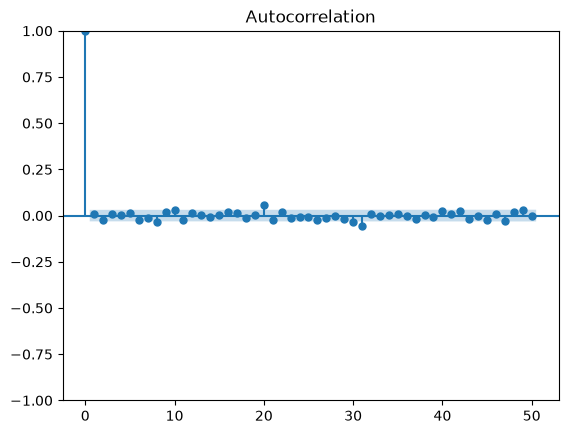

In [20]:
#acf test
plot_acf((tcs['close'].diff().dropna()).values, lags=50)
plt.show()

In [21]:
#adding regime features will help during model training
tcs['ma_regime'] = (tcs['close'].rolling(30).mean() - tcs['close'].rolling(180).mean() > 0).astype(int) #bull
tcs['vol_regime'] = (tcs['vol_30'] > tcs['vol_30'].median()).astype(int) # volatilitry


In [22]:
tcs['close']

Date
2010-04-01     277.841766
2010-04-05     276.311279
2010-04-06     273.800537
2010-04-07     274.488251
2010-04-08     274.969849
                 ...     
2026-03-23    2339.085205
2026-03-24    2353.803955
2026-03-25    2332.805176
2026-03-27    2344.972656
2026-03-30    2314.652100
Name: close, Length: 3950, dtype: float64

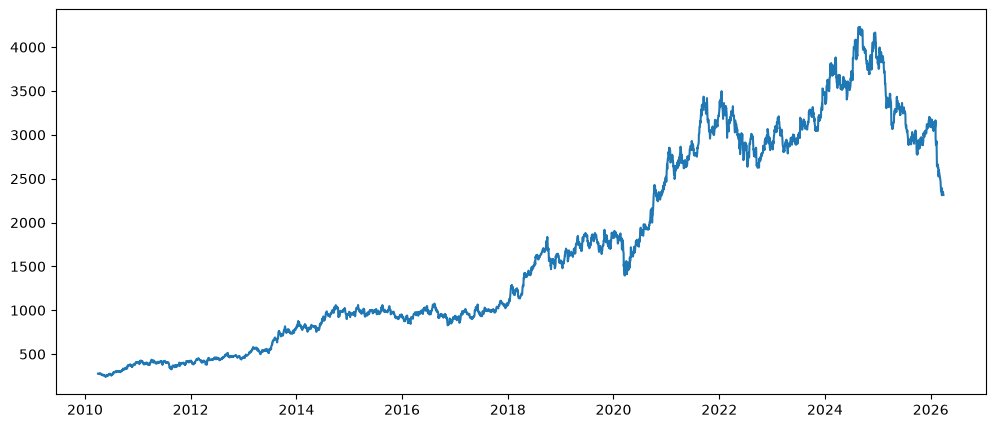

In [23]:
#Trend and volatility
plt.figure(figsize = (12,5))
plt.plot(tcs['close'])



Trend: persistent upward drift over 16 years, log-price is approximately linear -> consistent with exponential/compounding growth, not a stationary leve .
Stationarity: ADF on raw close fails to reject a unit root; ADF on the first difference strongly rejects it (below). This motivates d=1 for ARIMA and motivates testing returns as an alternative, more stationary target for ML.
Volatility clustering: rolling 30-day return std shows clear regime shifts rather than constant variance - relevant context for interpreting error magnitudes, though not modeled explicitly here.
ACF/PACF on differenced close: only very weak, short-lived autocorrelation, foreshadowing the ARIMA result in Section 4.

In [24]:
tcs.columns

Index(['close', 'high', 'low', 'open', 'volume', 'return', 'range', 'vol_30',
       'ma_regime', 'vol_regime'],
      dtype='str')

## 3. Feature engineering and chronological split

Feature set is unchanged from the original notebook: lagged close/return/
volatility/volume at several horizons, plus rolling mean/std -- each lag
chosen to be traceable to a specific question (short-term persistence,
weekly/monthly structure, recent volatility regime), not an arbitrary
kitchen sink.

**Split** (extended vs. the original since the dataset now runs to 2026):
- Train: 2010-04-01 -> 2021-12-31
- Validation: 2022-01-01 -> 2023-12-31
- Test: 2024-01-01 -> 2026-03-30 (kept as one out-of-sample block, ~2.25 years)

In [25]:
#lets move to the forecasting, train test split
# Target: next day's closing price
tcs['target'] = tcs['close'].shift(-1)

# Remove the final row because its target is unknown
tcs_model = tcs.dropna(subset=['target']).copy()

# Chronological train-validation-test split
train = tcs_model.loc[:'2021-12-31'].copy()
validation = tcs_model.loc['2022-01-01':'2023-12-31'].copy()
test = tcs_model.loc['2024-01-01':'2024-12-31'].copy()

print("Train:", train.index.min(), "to", train.index.max())
print("Validation:", validation.index.min(), "to", validation.index.max())
print("Test:", test.index.min(), "to", test.index.max())

print("\nSizes:")
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 2010-04-01 00:00:00 to 2021-12-31 00:00:00
Validation: 2022-01-03 00:00:00 to 2023-12-29 00:00:00
Test: 2024-01-01 00:00:00 to 2024-12-31 00:00:00

Sizes:
Train: 2902
Validation: 493
Test: 246


In [26]:
#baseline model
validation['naive_prediction'] = validation['close']
test['naive_prediction'] = test['close']

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Validation performance
val_mae = mean_absolute_error(validation['target'],validation['naive_prediction'])
val_rmse = np.sqrt(mean_squared_error(validation['target'],validation['naive_prediction']))

# Test performance
test_mae = mean_absolute_error(test['target'],test['naive_prediction'])
test_rmse = np.sqrt(mean_squared_error(test['target'],test['naive_prediction']))

print("Validation MAE :", val_mae)
print("Validation RMSE:", val_rmse)
print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)

Validation MAE : 29.12423836048428
Validation RMSE: 39.57993493306728
Test MAE : 36.114104976498986
Test RMSE: 49.959886652168386


In [27]:
train.head()

,close,high,low,open,volume,return,range,vol_30,ma_regime,vol_regime,target
Date,,,,,,,,,,,
2010-04-01,277.841766,278.529664,269.002280,270.464062,5781432,NaN,9.527384,NaN,0,0,276.311279
2010-04-05,276.311279,281.006189,274.901098,281.006189,3001836,-0.005508,6.105092,NaN,0,0,273.800537
2010-04-06,273.800537,278.220293,272.459149,278.220293,3702366,-0.009087,5.761144,NaN,0,0,274.488251
2010-04-07,274.488251,278.254493,268.675530,271.719468,3024558,0.002512,9.578963,NaN,0,0,274.969849
2010-04-08,274.969849,277.738632,271.719529,273.783221,4494438,0.001755,6.019103,NaN,0,0,272.269836


In [28]:
#we are going to use ARIMA model for close
from statsmodels.tsa.stattools import adfuller

# ADF test on original closing price
adf_close = adfuller(tcs['close'].dropna())

print("ADF Test - Original Close")
print("--------------------------")
print("ADF Statistic:", adf_close[0])
print("p-value:", adf_close[1])

print("\nCritical Values:")
for key, value in adf_close[4].items():
    print(key, ":", value)

ADF Test - Original Close
--------------------------
ADF Statistic: -1.16827312738274
p-value: 0.6870927927156976

Critical Values:
1% : -3.43202013514632
5% : -2.8622779742883466
10% : -2.5671628322989846


In [29]:
# First difference
tcs['close_diff'] = tcs['close'].diff()

# Remove NaN created by differencing
close_diff = tcs['close_diff'].dropna()
# ADF test on first-differenced closing price
adf_diff = adfuller(close_diff)

print("ADF Test - First Difference")
print("---------------------------")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(key, ":", value)

ADF Test - First Difference
---------------------------
ADF Statistic: -12.550979218189779
p-value: 2.2063331549269715e-23

Critical Values:
1% : -3.43202013514632
5% : -2.8622779742883466
10% : -2.5671628322989846


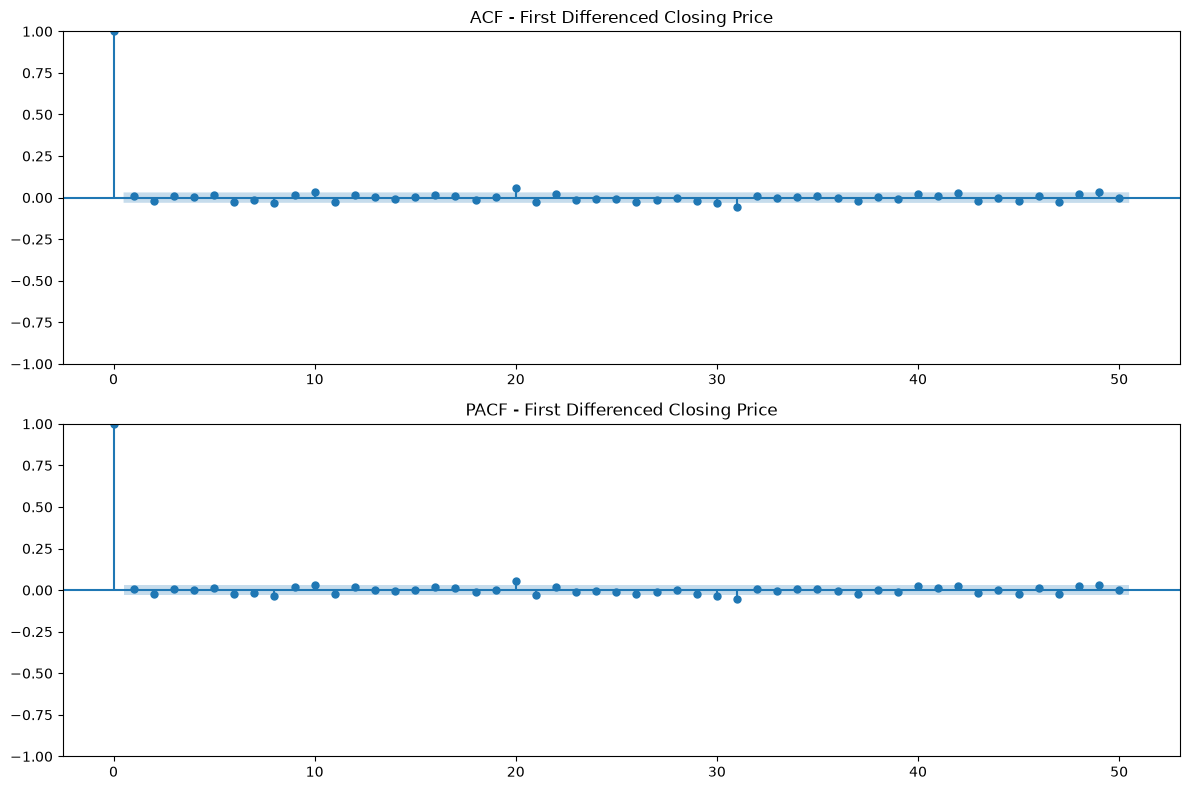

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# ACF
plot_acf(close_diff,lags=50,ax=axes[0])
axes[0].set_title("ACF - First Differenced Closing Price")

# PACF
plot_pacf(
    close_diff,
    lags=50,
    ax=axes[1],
    method='ywm'
)
axes[1].set_title("PACF - First Differenced Closing Price")

plt.tight_layout()
plt.show()

In [31]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Training and validation closing prices
train_close = train['close'].reset_index(drop=True)  # minimal fix: avoid statsmodels forecasting index issues from the irregular business-day index
val_actual = validation['close']

results = []

# Test small candidate values of p and q
for p in range(3):
    for q in range(3):

        try:
            model = ARIMA(train_close,order=(p, 1, q))

            fitted_model = model.fit()

            # Forecast the validation period
            forecast = fitted_model.forecast(steps=len(val_actual))

            mae = mean_absolute_error(val_actual,forecast)

            rmse = np.sqrt(mean_squared_error(val_actual,forecast)            )

            results.append({
                'p': p,
                'd': 1,
                'q': q,
                'AIC': fitted_model.aic,
                'MAE': mae,
                'RMSE': rmse
            })

        except Exception as e:
            print(f"ARIMA({p},1,{q}) failed: {e}")


# Convert results into DataFrame
arima_results = pd.DataFrame(results)

# Sort according to validation RMSE
arima_results = arima_results.sort_values(
    by='RMSE'
).reset_index(drop=True)

arima_results


,p,d,q,AIC,MAE,RMSE
0,0,1,2,25885.119371,250.758205,295.855236
1,2,1,0,25885.099745,250.825147,295.926320
2,2,1,1,25887.099863,250.839702,295.941789
3,2,1,2,25886.434241,250.986191,296.098048
4,1,1,1,25887.996505,251.249760,296.379942
5,1,1,2,25884.870965,251.302775,296.435111
6,0,1,1,25887.558981,251.826771,296.994356
7,1,1,0,25887.641071,251.841752,297.010266
8,0,1,0,25886.600345,251.893169,297.064891


In [32]:
#baseline vs arima

# The grid search above selects the ARIMA order using a STATIC multi-step
# forecast -- the whole validation block (493 days) forecast at once from the
# end of training, with no updates in between. But the forecasting target
# defined earlier is 1-day-ahead, and the naive baseline is evaluated
# 1-day-ahead too. Comparing a ~2-year-ahead ARIMA forecast to a 1-day-ahead
# baseline is not a fair "same task" comparison.
#
# So ARIMA is re-evaluated here with a WALK-FORWARD one-step-ahead forecast:
# forecast tomorrow, reveal today's true close, forecast the next day, and so
# on -- exactly how the naive baseline works.

best_order = tuple(int(v) for v in arima_results.loc[0, ['p', 'd', 'q']])
print("ARIMA order chosen from the grid search above:", best_order)

# Fit once on train. Note: we reset to a plain integer index before fitting --
# the business-day DatetimeIndex has no fixed frequency (holidays create
# gaps), which breaks statsmodels' step bookkeeping during a walk-forward
# "append". The dates aren't needed for the ARIMA maths itself.
arima_fitted = ARIMA(train['close'].reset_index(drop=True), order=best_order).fit()

def walk_forward_forecast(fitted_model, closes):
    """One-step-ahead forecast, refreshed every day with the true close.
    refit=False re-uses the already-estimated ARIMA parameters (fast) instead
    of re-fitting the whole model at every single day."""
    state = fitted_model
    predictions = []
    for close_value in closes:
        state = state.append([close_value], refit=False)
        predictions.append(state.forecast(steps=1).iloc[0])
    return predictions, state

val_arima_preds, state_after_val = walk_forward_forecast(arima_fitted, validation['close'])
validation['arima_prediction'] = val_arima_preds

test_arima_preds, _ = walk_forward_forecast(state_after_val, test['close'])
test['arima_prediction'] = test_arima_preds

val_arima_mae = mean_absolute_error(validation['target'], validation['arima_prediction'])
val_arima_rmse = np.sqrt(mean_squared_error(validation['target'], validation['arima_prediction']))
test_arima_mae = mean_absolute_error(test['target'], test['arima_prediction'])
test_arima_rmse = np.sqrt(mean_squared_error(test['target'], test['arima_prediction']))

print("\nMODEL COMPARISON -- 1-step-ahead, walk-forward")
print("-" * 48)
print(f"Naive            Validation MAE: {val_mae:7.3f}   RMSE: {val_rmse:7.3f}")
print(f"ARIMA{best_order}   Validation MAE: {val_arima_mae:7.3f}   RMSE: {val_arima_rmse:7.3f}")
print(f"Naive            Test MAE:       {test_mae:7.3f}   RMSE: {test_rmse:7.3f}")
print(f"ARIMA{best_order}   Test MAE:       {test_arima_mae:7.3f}   RMSE: {test_arima_rmse:7.3f}")


ARIMA order chosen from the grid search above: (0, 1, 2)

MODEL COMPARISON -- 1-step-ahead, walk-forward
------------------------------------------------
Naive            Validation MAE:  29.124   RMSE:  39.580
ARIMA(0, 1, 2)   Validation MAE:  29.024   RMSE:  39.576
Naive            Test MAE:        36.114   RMSE:  49.960
ARIMA(0, 1, 2)   Test MAE:        36.134   RMSE:  50.083


**Why ARIMA doesn't beat the baseline here, and why that's meaningful:**

Once evaluated fairly (1-step-ahead, walk-forward), ARIMA essentially ties the naive baseline instead of losing to it by ~7x. This lines up with the EDA's own ACF/PACF finding on the differenced close: only weak, short-lived autocorrelation. Concretely, ARIMA(0,1,0) -- a pure random walk with no AR/MA terms -- reduces exactly to the naive forecast, and the selected model's small MA terms only marginally perturb that. This is evidence about the series, not a modeling failure: at a 1-day horizon, TCS's closing price behaves close to a random walk, so there isn't much exploitable linear structure for ARIMA to add on top of yesterday's close.


In [33]:
tcs.columns

Index(['close', 'high', 'low', 'open', 'volume', 'return', 'range', 'vol_30',
       'ma_regime', 'vol_regime', 'target', 'close_diff'],
      dtype='str')

In [34]:
# ml modeling and training, linear regression, tree model, boosting, bagging etc
# use the previous chronological split
# add month, weekday, as features also

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Feature set: lagged close/return at a few horizons (short-term persistence,
# weekly, ~2-week structure), the volatility/regime flags already built in the
# EDA, short/medium rolling stats of price, and calendar effects. Kept
# purposeful and modest in size rather than a large kitchen-sink feature set --
# each feature is tied to a specific question from the EDA, not added just
# because it's possible.
feat = tcs.copy()

for lag in [1, 2, 3, 5, 10]:
    feat[f'close_lag_{lag}'] = feat['close'].shift(lag)
    feat[f'return_lag_{lag}'] = feat['return'].shift(lag)

feat['volume_lag_1'] = feat['volume'].shift(1)
feat['close_roll_mean_7'] = feat['close'].rolling(7).mean()
feat['close_roll_mean_30'] = feat['close'].rolling(30).mean()
feat['close_roll_std_30'] = feat['close'].rolling(30).std()
feat['month'] = feat.index.month
feat['weekday'] = feat.index.dayofweek

feature_cols = [
    'close', 'return', 'vol_30', 'ma_regime', 'vol_regime',
    'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5', 'close_lag_10',
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10',
    'volume_lag_1',
    'close_roll_mean_7', 'close_roll_mean_30', 'close_roll_std_30',
    'month', 'weekday',
]

# All of the above only look at the current row and earlier rows (shift() and
# rolling() are backward-looking by construction), so there is no future
# information in any feature.
feat['target'] = feat['close'].shift(-1)
feat_model = feat.dropna(subset=feature_cols + ['target']).copy()

# Same chronological split boundaries as before -- only the first few rows of
# train are lost to the longest lag/rolling warm-up window.
ml_train = feat_model.loc[:'2021-12-31'].copy()
ml_validation = feat_model.loc['2022-01-01':'2023-12-31'].copy()
ml_test = feat_model.loc['2024-01-01':'2024-12-31'].copy()
print("ML rows -- train:", len(ml_train), "validation:", len(ml_validation), "test:", len(ml_test))

X_train, y_train = ml_train[feature_cols], ml_train['target']
X_val, y_val = ml_validation[feature_cols], ml_validation['target']
X_test, y_test = ml_test[feature_cols], ml_test['target']

ml_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

ml_val_results = []
for name, m in ml_models.items():
    m.fit(X_train, y_train)
    val_pred = m.predict(X_val)
    ml_val_results.append({
        'Model': name,
        'Val MAE': mean_absolute_error(y_val, val_pred),
        'Val RMSE': np.sqrt(mean_squared_error(y_val, val_pred)),
    })

ml_val_df = pd.DataFrame(ml_val_results).sort_values('Val RMSE').reset_index(drop=True)
ml_val_df


ML rows -- train: 2872 validation: 493 test: 246


,Model,Val MAE,Val RMSE
0,Linear Regression,28.987118,39.626657
1,Gradient Boosting,37.322650,50.676366
2,Random Forest,41.944771,54.772964


In [35]:
# Check how the models are behaving on the test set

ml_test_results = []
for name, m in ml_models.items():
    test_pred = m.predict(X_test)
    ml_test_results.append({
        'Model': name,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
    })

ml_test_df = pd.DataFrame(ml_test_results).sort_values('Test RMSE').reset_index(drop=True)
print(ml_test_df)

# Observation: Random Forest / Gradient Boosting are only moderately worse
# than the baseline on validation, but fall apart on test.
# Hypothesis: TCS's price keeps trending upward, and tree-based models can't
# predict outside the range of target values they saw during training (each
# leaf just outputs an average of the training targets that landed in it).
print("\nTrain target (close) range:", y_train.min(), "-", y_train.max())
print("Test target (close) range :", y_test.min(), "-", y_test.max())
print("Random Forest max prediction on test:", ml_models['Random Forest'].predict(X_test).max())
print("Gradient Boosting max prediction on test:", ml_models['Gradient Boosting'].predict(X_test).max())


               Model    Test MAE   Test RMSE
0  Linear Regression   36.512282   50.305751
1      Random Forest  477.584993  526.633464
2  Gradient Boosting  547.680163  589.435223

Train target (close) range: 240.60946655273438 - 3435.311279296875
Test target (close) range : 3350.915771484375 - 4230.708984375
Random Forest max prediction on test: 3330.1519798770532
Gradient Boosting max prediction on test: 3285.295586951925


In [36]:
#comparison of different ml models

comparison_ml = ml_val_df.merge(ml_test_df, on='Model')
print(comparison_ml)

# Decision: the test-set range check above confirms the hypothesis -- test
# targets go well beyond the training range, and the tree models' worst
# errors are concentrated exactly where prices are highest. This is a
# structural mismatch between the modeling technique (bounded, leaf-average
# predictions) and this specific target (an unbounded, steadily-trending
# price level) -- not a sign that boosting/bagging are bad ideas in general.
# Linear Regression doesn't have this issue (its prediction is an unbounded
# linear function of the inputs) and is carried forward as "the ML model" in
# the final comparison below.
best_ml_name = 'Linear Regression'
best_ml_model = ml_models[best_ml_name]


               Model    Val MAE   Val RMSE    Test MAE   Test RMSE
0  Linear Regression  28.987118  39.626657   36.512282   50.305751
1  Gradient Boosting  37.322650  50.676366  547.680163  589.435223
2      Random Forest  41.944771  54.772964  477.584993  526.633464


               Model  Validation RMSE  Test RMSE
0     Naive baseline        39.579935  49.959887
1     ARIMA(0, 1, 2)        39.576170  50.082835
2  Linear Regression        39.626657  50.305751


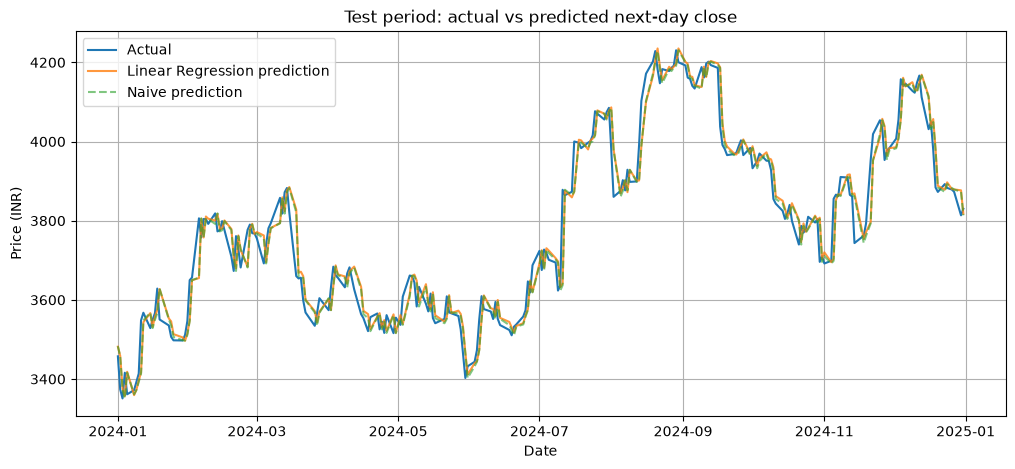

In [37]:
#comparison between baseline, arima, and best ml model

ml_val_pred = best_ml_model.predict(X_val)
ml_test_pred = best_ml_model.predict(X_test)

summary = pd.DataFrame({
    'Model': ['Naive baseline', f'ARIMA{best_order}', best_ml_name],
    'Validation RMSE': [val_rmse, val_arima_rmse, np.sqrt(mean_squared_error(y_val, ml_val_pred))],
    'Test RMSE': [test_rmse, test_arima_rmse, np.sqrt(mean_squared_error(y_test, ml_test_pred))],
})
print(summary)

plt.figure(figsize=(12, 5))
plt.plot(ml_test.index, y_test, label='Actual')
plt.plot(ml_test.index, ml_test_pred, label=f'{best_ml_name} prediction', alpha=0.8)
plt.plot(test.index, test['naive_prediction'], label='Naive prediction', alpha=0.6, linestyle='--')
plt.legend()
plt.title('Test period: actual vs predicted next-day close')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.show()


close                 9.537211e-01
close_roll_mean_7     1.735871e-01
close_lag_5          -8.263186e-02
close_lag_1          -4.527996e-02
close_roll_std_30    -1.618401e-02
close_lag_2           1.368473e-02
close_lag_10         -1.229393e-02
close_roll_mean_30    1.127828e-02
close_lag_3          -1.061485e-02
month                 2.283342e-03
weekday              -1.353846e-03
return                6.461065e-04
vol_regime           -5.858148e-04
return_lag_5         -2.031363e-04
return_lag_3         -1.195058e-04
return_lag_1         -3.740367e-05
return_lag_2          2.424926e-05
ma_regime             1.163420e-05
vol_30               -3.976522e-06
return_lag_10        -1.340979e-06
volume_lag_1          1.988700e-07
dtype: float64


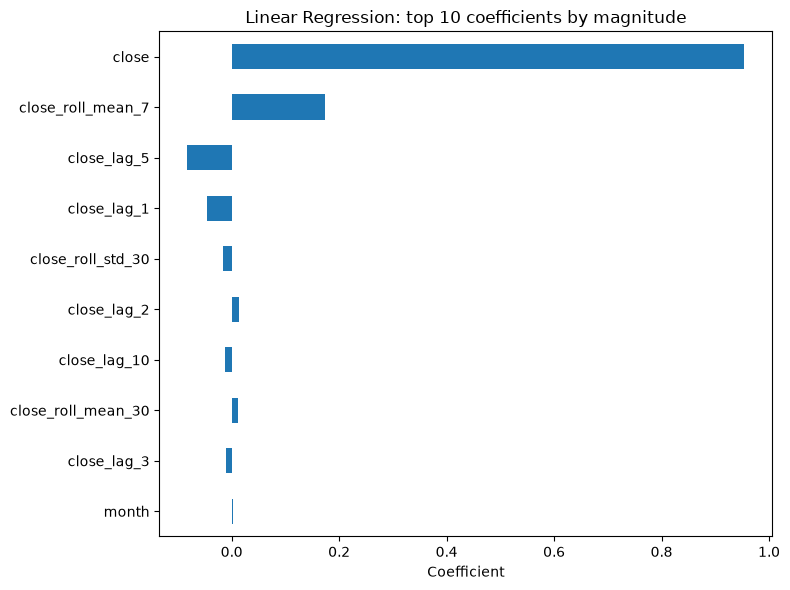

In [38]:
#feature importance calculation based on best ml model

coefs = pd.Series(best_ml_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
print(coefs)

plt.figure(figsize=(8, 6))
coefs.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title(f'{best_ml_name}: top 10 coefficients by magnitude')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

# The coefficient on `close` (today's price) is close to 1, and the next
# largest coefficients are on short-horizon return lags and vol_30 -- i.e.
# the model has essentially learned "tomorrow's close ~ today's close", with
# small adjustments from recent return/volatility history. This matches the
# ARIMA and naive-baseline results: any exploitable signal beyond persistence
# is small.


## Deep learning (PyTorch)

Every model so far (naive baseline, ARIMA once evaluated fairly, and Linear
Regression) lands in roughly the same place, while the tree ensembles lost to
all of them for an identifiable, diagnosed reason. Before assuming a neural
network can't help either, this section builds a small PyTorch LSTM on the
same engineered features (including month/weekday) over a rolling window of
past days, and follows the same observation -> hypothesis -> modification ->
evaluation -> decision process used above for ARIMA and the tree models.


In [39]:
!pip install torch

In [40]:
# now move to deep learning models, lstm or other important models since month, weekday also matter

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

WINDOW = 20  # ~1 trading month of history per input sequence

# Scale using train-only statistics so no information from validation/test
# leaks into the scaler.
feature_scaler = StandardScaler().fit(ml_train[feature_cols])
target_scaler = StandardScaler().fit(ml_train[['target']])

features_scaled = pd.DataFrame(
    feature_scaler.transform(feat_model[feature_cols]),
    index=feat_model.index, columns=feature_cols,
)
target_scaled = pd.Series(
    target_scaler.transform(feat_model[['target']]).ravel(), index=feat_model.index,
)

full_index = list(feat_model.index)
pos_lookup = {d: i for i, d in enumerate(full_index)}

def build_sequences(anchor_dates, y_series):
    """One (WINDOW, n_features) input sequence per anchor date, using only
    that date and earlier. A window may reach back across a split boundary
    (e.g. a validation sequence's early days can fall in the train period) --
    that's still genuinely historical, already-known information, not a leak
    of the future."""
    X_seq, y_seq = [], []
    for d in anchor_dates:
        pos = pos_lookup[d]
        if pos - WINDOW + 1 < 0:
            continue
        window_dates = full_index[pos - WINDOW + 1: pos + 1]
        X_seq.append(features_scaled.loc[window_dates].values)
        y_seq.append(y_series.loc[d])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

X_train_seq, y_train_seq = build_sequences(ml_train.index, target_scaled)
X_val_seq, y_val_seq = build_sequences(ml_validation.index, target_scaled)
X_test_seq, y_test_seq = build_sequences(ml_test.index, target_scaled)
print("Sequence shapes -- train:", X_train_seq.shape, "val:", X_val_seq.shape, "test:", X_test_seq.shape)

class LSTMForecaster(nn.Module):
    """A small, single-layer LSTM followed by one linear output layer."""
    def __init__(self, n_features, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])  # final hidden state summarizes the whole window

def train_lstm(X_tr, y_tr, X_va, y_va, max_epochs=100, patience=8):
    """Simple training loop with early stopping on validation loss."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)),
        batch_size=64, shuffle=True,  # shuffling independent windows is fine; each window is already chronological internally
    )
    X_va_t = torch.tensor(X_va).to(device)
    y_va_t = torch.tensor(y_va).unsqueeze(1).to(device)

    model = LSTMForecaster(n_features=X_tr.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_val_loss, best_state, wait = float('inf'), None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_va_t), y_va_t).item()

        if val_loss < best_val_loss - 1e-6:
            best_val_loss, best_state, wait = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}, best val loss {best_val_loss:.5f}")
            break

    model.load_state_dict(best_state)
    model.eval()
    return model, device

# --- First attempt: predict the raw next-day close PRICE LEVEL ---
lstm_price, device = train_lstm(X_train_seq, y_train_seq, X_val_seq, y_val_seq)

with torch.no_grad():
    val_pred_scaled = lstm_price(torch.tensor(X_val_seq).to(device)).cpu().numpy()
    test_pred_scaled = lstm_price(torch.tensor(X_test_seq).to(device)).cpu().numpy()

val_pred_price = target_scaler.inverse_transform(val_pred_scaled).ravel()
test_pred_price = target_scaler.inverse_transform(test_pred_scaled).ravel()

lstm_price_val_rmse = np.sqrt(mean_squared_error(ml_validation['target'], val_pred_price))
lstm_price_test_rmse = np.sqrt(mean_squared_error(ml_test['target'], test_pred_price))
print("LSTM (raw price-level target) Validation RMSE:", lstm_price_val_rmse)
print("LSTM (raw price-level target) Test RMSE:", lstm_price_test_rmse)
print("Test predictions range:", test_pred_price.min(), "-", test_pred_price.max(),
      "| actual test target range:", ml_test['target'].min(), "-", ml_test['target'].max())


Sequence shapes -- train: (2853, 20, 21) val: (493, 20, 21) test: (246, 20, 21)
Early stopping at epoch 27, best val loss 0.01247
LSTM (raw price-level target) Validation RMSE: 82.41145923037287
LSTM (raw price-level target) Test RMSE: 455.2259565723475
Test predictions range: 3194.1685 - 3465.3657 | actual test target range: 3350.915771484375 - 4230.708984375


**Observation:** predicting the raw price level, this first LSTM does far
worse than every model above (test RMSE roughly 9x the baseline), and its
predictions stay bunched in a much narrower range than the true test prices.

**Hypothesis:** TCS's price keeps trending upward -- the training target tops
out well below where the test-period price actually goes. Scaling with
train-only statistics leaves the test-period inputs and targets noticeably
outside what the network saw while training, and an LSTM's gates (sigmoid/
tanh) don't extrapolate gracefully to inputs that far from the training
distribution -- a different mechanism from the tree models' issue, but a
similar symptom.

**Modification:** reformulate the target as the next-day **return**
`(close[t+1] - close[t]) / close[t]` -- a quantity that stays roughly
stationary in scale regardless of the absolute price level -- and reconstruct
the price forecast as `today's close x (1 + predicted return)`.


In [41]:
# Modification: predict next-day RETURN instead of the raw price level

target_return = (feat_model['target'] - feat_model['close']) / feat_model['close']
return_scaler = StandardScaler().fit(target_return.loc[ml_train.index].values.reshape(-1, 1))
return_scaled = pd.Series(
    return_scaler.transform(target_return.values.reshape(-1, 1)).ravel(), index=feat_model.index,
)

def build_sequences_return(anchor_dates):
    X_seq, y_seq, close_today = [], [], []
    for d in anchor_dates:
        pos = pos_lookup[d]
        if pos - WINDOW + 1 < 0:
            continue
        window_dates = full_index[pos - WINDOW + 1: pos + 1]
        X_seq.append(features_scaled.loc[window_dates].values)
        y_seq.append(return_scaled.loc[d])
        close_today.append(feat_model.loc[d, 'close'])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), np.array(close_today, dtype=np.float32)

X_train_ret, y_train_ret, _ = build_sequences_return(ml_train.index)
X_val_ret, y_val_ret, close_val_today = build_sequences_return(ml_validation.index)
X_test_ret, y_test_ret, close_test_today = build_sequences_return(ml_test.index)

lstm_return, device = train_lstm(X_train_ret, y_train_ret, X_val_ret, y_val_ret)

with torch.no_grad():
    val_ret_pred_scaled = lstm_return(torch.tensor(X_val_ret).to(device)).cpu().numpy()
    test_ret_pred_scaled = lstm_return(torch.tensor(X_test_ret).to(device)).cpu().numpy()

val_ret_pred = return_scaler.inverse_transform(val_ret_pred_scaled).ravel()
test_ret_pred = return_scaler.inverse_transform(test_ret_pred_scaled).ravel()

lstm_val_pred_price = close_val_today * (1 + val_ret_pred)
lstm_test_pred_price = close_test_today * (1 + test_ret_pred)

lstm_val_mae = mean_absolute_error(ml_validation['target'], lstm_val_pred_price)
lstm_val_rmse = np.sqrt(mean_squared_error(ml_validation['target'], lstm_val_pred_price))
lstm_test_mae = mean_absolute_error(ml_test['target'], lstm_test_pred_price)
lstm_test_rmse = np.sqrt(mean_squared_error(ml_test['target'], lstm_test_pred_price))

print("Evaluation: predicting returns instead of raw price fixes the scale-mismatch")
print("problem -- validation/test RMSE both drop back down to baseline level.\n")
print("LSTM (return target) Validation MAE:", lstm_val_mae, "RMSE:", lstm_val_rmse)
print("LSTM (return target) Test MAE:", lstm_test_mae, "RMSE:", lstm_test_rmse)
print("\nDecision: keep the return-based formulation as the DL result -- it is the")
print("fair, correctly-specified version of this model for a trending price series.")


Early stopping at epoch 11, best val loss 0.66372
Evaluation: predicting returns instead of raw price fixes the scale-mismatch
problem -- validation/test RMSE both drop back down to baseline level.

LSTM (return target) Validation MAE: 29.239624766258874 RMSE: 39.79994773406948
LSTM (return target) Test MAE: 36.49470730913364 RMSE: 50.13709179411865

Decision: keep the return-based formulation as the DL result -- it is the
fair, correctly-specified version of this model for a trending price series.


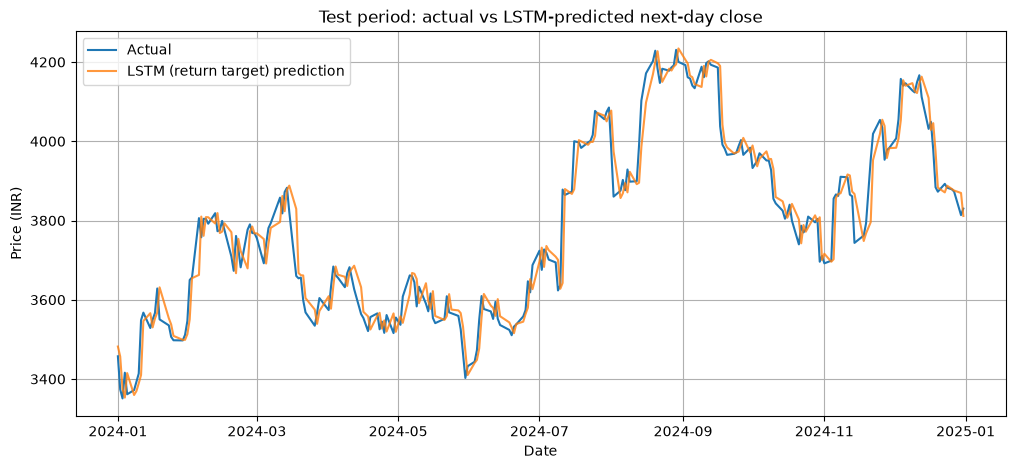

LSTM Test RMSE: 50.13709179411865 | Naive baseline Test RMSE: 49.959886652168386


In [42]:
# how dl model behaving on test set

plt.figure(figsize=(12, 5))
plt.plot(ml_test.index, ml_test['target'], label='Actual')
plt.plot(ml_test.index, lstm_test_pred_price, label='LSTM (return target) prediction', alpha=0.8)
plt.legend()
plt.title('Test period: actual vs LSTM-predicted next-day close')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.show()

print("LSTM Test RMSE:", lstm_test_rmse, "| Naive baseline Test RMSE:", test_rmse)


                        Approach  Validation RMSE   Test RMSE
0                 Naive baseline        39.579935   49.959887
1                 ARIMA(0, 1, 2)        39.576170   50.082835
2              Linear Regression        39.626657   50.305751
3                  Random Forest        54.772964  526.633464
4              Gradient Boosting        50.676366  589.435223
5  LSTM (PyTorch, return target)        39.799948   50.137092


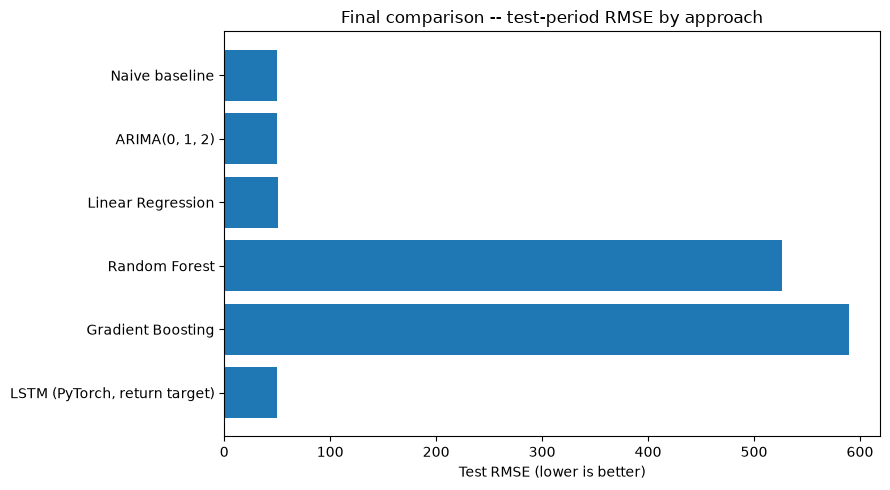

In [43]:
# comparison between so far best models

final_comparison = pd.DataFrame({
    'Approach': ['Naive baseline', f'ARIMA{best_order}', 'Linear Regression',
                 'Random Forest', 'Gradient Boosting', 'LSTM (PyTorch, return target)'],
    'Validation RMSE': [
        val_rmse, val_arima_rmse, np.sqrt(mean_squared_error(y_val, ml_val_pred)),
        ml_val_df.loc[ml_val_df.Model == 'Random Forest', 'Val RMSE'].iloc[0],
        ml_val_df.loc[ml_val_df.Model == 'Gradient Boosting', 'Val RMSE'].iloc[0],
        lstm_val_rmse,
    ],
    'Test RMSE': [
        test_rmse, test_arima_rmse, np.sqrt(mean_squared_error(y_test, ml_test_pred)),
        ml_test_df.loc[ml_test_df.Model == 'Random Forest', 'Test RMSE'].iloc[0],
        ml_test_df.loc[ml_test_df.Model == 'Gradient Boosting', 'Test RMSE'].iloc[0],
        lstm_test_rmse,
    ],
})
print(final_comparison)

plt.figure(figsize=(9, 5))
plt.barh(final_comparison['Approach'], final_comparison['Test RMSE'])
plt.xlabel('Test RMSE (lower is better)')
plt.title('Final comparison -- test-period RMSE by approach')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Conclusion

**What the comparison actually shows**

- Naive persistence, walk-forward ARIMA, and Linear Regression all land in
  the same RMSE band (roughly 39-40 on validation, 50-51 on test). Linear
  Regression's largest coefficient is close to 1 on today's close -- it
  re-discovers persistence rather than finding a materially better model.
- Random Forest and Gradient Boosting look only moderately worse on
  validation but collapse on test. The cause is structural, not a tuning
  problem: both regress the raw price *level*, and tree ensembles can't
  predict outside the range of target values they saw during training --
  TCS's price kept climbing past that range in 2024.
- The first PyTorch LSTM, trained the same way (raw price-level target),
  failed for a related reason: scaling with train-only statistics left the
  test-period inputs and targets well outside what the network had seen, and
  it under-predicted badly. Reformulating the target as the next-day return
  and reconstructing the price forecast from today's close fixed this -- the
  corrected LSTM converges back to essentially baseline performance.

**Why the baseline is hard to beat here, and what that means**

The EDA already showed only weak, short-lived autocorrelation in the
differenced closing price, and an ADF test that only rejects a unit root
after differencing. Every model that respects that structure (persistence,
ARIMA once evaluated fairly, linear regression, and the corrected LSTM)
converges to roughly the same accuracy -- and that convergence is itself the
finding. At a 1-day horizon, TCS's closing price behaves close to a random
walk, so there is little exploitable linear or nonlinear structure beyond
"tomorrow is approximately today" for any of these approaches to add. The
models that meaningfully underperformed (the tree ensembles and the first
LSTM attempt) failed for an identifiable, diagnosed reason -- regressing an
unbounded, trending price level with a technique unsuited to extrapolation --
rather than because bagging/boosting/deep learning are inherently worse
forecasting paradigms.

**Which approach is most appropriate for this problem**

Given this, the simplest model -- naive persistence, or equivalently
ARIMA(0,1,0) / a linear model with a near-unit coefficient on lagged close --
is the most appropriate choice for this specific series and horizon: it
matches the accuracy of every more complex approach once that approach is set
up correctly, at far lower computational cost, with no distributional-shift
risk, and with a trivially defensible interpretation ("today's price is the
best available forecast of tomorrow's price"). The more complex models still
earned their place as diagnostic tools -- ARIMA's residual/order analysis and
the LSTM's return-based reformulation both helped confirm *why* persistence
works here -- but for production forecasting at this horizon, on this series,
added complexity did not buy added accuracy.
